In [1]:

from pathlib import Path
import time
import numpy as np
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps, cumtrapz  # ADD cumtrapz HERE
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18 as cosmo, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

In [2]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "D0"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"

TELESCOPE_PARAMS = {


    "d0": {
        "D":12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 2048,
        "tsamp": 1.e-3,

    },

    "5d0": {
        "D":5*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    },

    "25d0": {
        "D":25*12,
        "eta": 0.6,
        "Trec": 22,
        "Tsky": 3,
        "BW": 300e6,
        "nu_cen": 1.4e9,
        "n_comp": 16,
        "n_chan": 1024,
        "tsamp": 1.e-3,

    }
}


In [3]:
alpha_intrinsic = -1  # Fixed intrinsic spectral index

In [4]:

# EFFECT CONTROL FLAGS
# ============================================================================
USE_COSMOLOGY = True      # Tozggle Euclidean vs cosmological universe (affects distances, volumes)
USE_SFR = True           
USE_SMEARING = True      
USE_SPECTRAL_INDEX = True 


# USE_COSMOLOGY = False
# USE_SFR = False           
# USE_SMEARING = False    
# USE_SPECTRAL_INDEX = False

USE_BEAM = True
# USE_BEAM = False

# # Luminosity function parameters
LUMINOSITY_FUNCTION = "schechter"  
# LUMINOSITY_FUNCTION = "std" 

In [5]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
# n_dishes = params.get("n_dishes", 1)
# mode = params.get("mode", "single")

# n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1
# array_gain_factor = n_dishes if mode == "coherent" else np.sqrt(n_dishes) if mode == "incoherent" else 1
G0 = np.pi * D*D/4 * eta/2.0/k*1e-26
Np = 2
Trec = params["Trec"]
Tsky = params["Tsky"]
BW = params["BW"]
n_comp = params["n_comp"]
BW_comp = BW / n_comp
n_chan = params["n_chan"]
BW_chan = BW / n_chan
nu_cen = params["nu_cen"]
nu_min = nu_cen - BW / 2
nu_max = nu_cen + BW / 2
nu_array = np.linspace(nu_min, nu_max, n_comp+1)

print(f"{'='*100}")
print(f"TELESCOPE: {TELESCOPE}")
print(f"  Diameter: {D} m")
print(f"  Receiver temp: {Trec} K")
print(f"  Bandwidth: {BW/1e6:.0f} MHz at {nu_cen/1e9:.3f} GHz")
# print(f"  N_dishes: {n_dishes}, Mode: {mode}")
# print(f"  FoV: {params['fov']} deg²")
print(f"{'='*100}\n")


TELESCOPE: D0
  Diameter: 12 m
  Receiver temp: 22 K
  Bandwidth: 300 MHz at 1.400 GHz



In [6]:
# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.01
z_min = 0.01
z_max = 5.0
z_array_opt = np.arange(z_min, z_max, dz)

# Options: "schechter" or "std"

L_STAR = 1e15  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.5  # Faint-end slope
L_MIN_SCH = 1e10
L_MAX_SCH = 1e16

L_std = 2.4e14  # Jy·kpc²

# Simulation parameters
theta_max = 2*1.22*c/D/nu_min # please note here
fscale = 0.2 * 1e-7  # FRB rate scaling factor

SNR_threshold = 10
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

fwhm_rad = 1.22 * (c / nu_min) / D
fwhm_deg = fwhm_rad * (180 / np.pi)
r_deg = 2.0 * fwhm_deg
area = np.pi * (r_deg)**2
# area = params['fov']  # Area of sky in square degrees

# Calculate frequency-dependent scattering term
freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])

np.random.seed(42)


In [7]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

# Pre-calculate constants for speed
_COEFF_CONST = (2.355**2) / (2 * 1.22**2 * (3.0e8**2))

def gaussian_beam_gain_fast(nu_array, G0, theta, D):
    """Optimized version for the inner loop"""
    coeff = theta**2 * D**2 * _COEFF_CONST
    return G0 * np.exp(-coeff * nu_array**2)

def tophat_beam_gain(nu, G0, theta, theta_max):
    """Tophat beam: constant G0 within theta_max/2, zero outside."""
    gain = G0 if theta <= (theta_max / 2) else 0.0
    return np.full_like(nu, gain, dtype=float) if np.ndim(nu) else float(gain)

def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [8]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [9]:
def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    # REMOVE THIS LINE:
    # from scipy.integrate import cumtrapz
    
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

In [10]:

# ============================================================================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

def std_sampler(L_candle):
    """Return a fixed luminosity sampler for standard candle model"""
    def sampler(u):
        return L_candle
    return sampler

Creating truncated Schechter samplers...
  Done!



In [11]:
# ============================================================================
# MULTI-TELESCOPE COMPARISON WITH SPECTRAL INDEX INFERENCE
# ============================================================================

print("\n" + "="*100)
print("RUNNING 3-TELESCOPE COMPARISON WITH SPECTRAL INDEX INFERENCE")
print("="*100 + "\n")

# Store results for each telescope
all_results = {}
colors_tel = {
    "d0": "#1f77b4",      # blue
    "5d0": "#ff7f0e",     # orange
    "25d0": "#2ca02c"     # green
}
labels_tel = {
    "d0": "D0 (12m)",
    "5d0": "5D0 (60m)",
    "25d0": "25D0 (300m)"
}

# Save original telescope parameters
D_orig = D
G0_orig = G0
theta_max_orig = theta_max
params_orig = params.copy()

# Define once for the Euclidean branch
H0_km_s_Mpc = cosmo.H0.value if hasattr(cosmo, "H0") else 70.0
DH_Mpc = 299792.458 / H0_km_s_Mpc

# Store inferred alpha SEPARATELY FOR EACH TELESCOPE
alpha_inferred_by_telescope = {
    "d0": [],
    "5d0": [],
    "25d0": []
}
alpha_error_by_telescope = {
    "d0": [],
    "5d0": [],
    "25d0": []
}
snr_by_telescope = {
    "d0": [],
    "5d0": [],
    "25d0": []
}

# Loop through all telescopes
for tel_key in ["d0", "5d0", "25d0"]:
    print(f"\n{'='*60}")
    print(f"TELESCOPE: {labels_tel[tel_key]}")
    print(f"{'='*60}")

    # Update telescope parameters
    params = TELESCOPE_PARAMS[tel_key]
    D = params["D"]
    G0 = np.pi * D * D / 4 * eta / 2.0 / k * 1e-26
    theta_max = 2 * 1.22 * c / D / nu_min

    # Recalculate area for this telescope
    fwhm_rad = 1.22 * (c / nu_min) / D
    fwhm_deg = fwhm_rad * (180 / np.pi)
    r_deg = 2.0 * fwhm_deg
    area_tel = np.pi * (r_deg)**2

    print(f"  Diameter: {D} m, G0: {G0:.4e}, theta_max: {theta_max:.6f}")
    print(f"  Sky area: {area_tel:.4f} deg²")

    # Independent seed for repeatability
    np.random.seed(42)

    # Re-compute L_min_by_z for this telescope
    L_min_by_z_new = {}
    nu0 = nu_cen

    for z in z_array_opt:
        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0   # kpc
        else:
            dl = (DH_Mpc * z) * 1000.0                          # kpc

        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
        
        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        L_min = S_min * (dl**2) * z_factor
        L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)

    sampler_cache.clear()

    # Run simulation for this telescope
    results_tel = []
    _INNER_COEFF_CONST_new = (D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)

    if USE_SPECTRAL_INDEX:
        nu_scaling = (nu_array / nu0)**alpha_intrinsic
    else:
        nu_scaling = np.ones_like(nu_array)

    for z_idx, z in enumerate(z_array_opt):
        zmin = z - 0.5 * dz
        zmax = z + 0.5 * dz
        L_min_z = L_min_by_z_new[z]

        if LUMINOSITY_FUNCTION.lower() == "std":
            if L_min_z > L_std:
                break
        else:
            if L_min_z > 8.952e15:
                break

        if LUMINOSITY_FUNCTION.lower() == "std":
            truncated_sampler = std_sampler(L_std)
        else:
            if L_min_z not in sampler_cache:
                sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                    L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                )
            truncated_sampler = sampler_cache[L_min_z]

        DM = 1000 * z
        wi_z = 0.001 * (1 + z)
        BW_chan_MHz = BW_chan / 1e6
        nu_cen_GHz = nu_cen / 1e9

        if USE_SMEARING:
            w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz**3)
            w_scatter_comp = (
                1.9e-7 * (DM**1.5) * (1 + (DM**3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
            )
            w_scatter = np.sqrt(np.sum(w_scatter_comp**2) / len(w_scatter_comp))
            w_sampling = params["tsamp"] * 1e-3
        else:
            w_DM = 0.0
            w_scatter = 0.0
            w_sampling = 0.0

        w_obs_factor = np.sqrt(wi_z**2 + w_DM**2 + w_scatter**2 + w_sampling**2)

        if USE_COSMOLOGY:
            dl = cosmo.luminosity_distance(z).value * 1000.0
        else:
            dl = (DH_Mpc * z) * 1000.0

        if USE_SPECTRAL_INDEX:
            z_factor = (1 + z)**(-1 - alpha_intrinsic)
        else:
            z_factor = 1.0

        theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0**2))

        # ===== INITIALIZE TRACKING ARRAYS FOR THIS Z-SHELL =====
        shell_alpha_inferred = []
        shell_alpha_error = []
        shell_snr_coherent = []

        n_generated = 0
        n_detected = 0
        detected_luminosities = []
        detected_snrs = []
        max_iterations = 1000000

        while n_detected < TARGET_DETECTIONS and n_generated < max_iterations:
            n_generated += 1
            theta_frb = theta_max * np.sqrt(np.random.random())

            if theta_frb > 4.0 * theta_hp:
                continue

            lum = float(truncated_sampler(np.random.uniform(0, 1)))
            S0_frb = (lum / (dl**2 * z_factor)) * (wi_z / w_obs_factor)
            S_nu = S0_frb * nu_scaling

            if USE_BEAM:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * theta_frb**2) * nu_array**2)
            else:
                G_nu = G0 * np.exp(-(_INNER_COEFF_CONST_new * 0.0**2) * nu_array**2)

            snr_spectrum = S_nu * G_nu * S_SNR_CONST
            snr_coherent = np.sum(snr_spectrum) / np.sqrt(n_comp)

            if snr_coherent > SNR_threshold:
                n_detected += 1
                detected_luminosities.append(lum)
                detected_snrs.append(snr_coherent)
                
                # ===== SPECTRAL INDEX INFERENCE =====
                shell_snr_coherent.append(snr_coherent)
                
                try:
                    # Use ALL channels for fitting
                    nu_fit = nu_array
                    snr_fit = snr_spectrum  # Use all channels
                    
                    # Prepare for Log-Log Fit
                    log_nu = np.log10(nu_fit / nu0)
                    log_snr = np.log10(snr_fit)
                    
                    # Calculate Uncertainties in Log Space
                    # SNR uncertainty = 1.0 (by definition)
                    # Error propagation: sigma_log_y = sigma_y / (y * ln(10))
                    sigma_log_snr = 1.0 / (snr_fit * np.log(10))
                    
                    # Weights = 1 / variance
                    weights = 1.0 / sigma_log_snr**2
                    
                    # Weighted Linear Regression with covariance
                    coeffs = np.polyfit(log_nu, log_snr, 1, w=weights, cov=True)
                    slope = coeffs[0][0]
                    cov_matrix = coeffs[1]
                    sigma_slope = np.sqrt(cov_matrix[0, 0])
                    
                    shell_alpha_inferred.append(slope)
                    shell_alpha_error.append(sigma_slope)
                    
                except Exception as e:
                    shell_alpha_inferred.append(np.nan)
                    shell_alpha_error.append(np.nan)

        if n_detected == TARGET_DETECTIONS:
            detection_rate = n_detected / n_generated

            if LUMINOSITY_FUNCTION.lower() == "std":
                N_ratio = 1.0 if L_std >= L_min_z else 0.0
            else:
                L_grid_full = np.logspace(10, 16, 5000)
                phi_grid_full = schechter_function(L_grid_full, L_STAR, ALPHA_SCH)
                cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)
                cdf_full /= cdf_full[-1]
                cdf_interp = interp1d(L_grid_full, cdf_full, kind="linear")
                N_ratio = 1.0 - cdf_interp(L_min_z)

            if USE_COSMOLOGY:
                dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                dvol = (
                    cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value
                ) * (area_tel / (4.0 * np.pi * ((180.0 / np.pi)**2)))
            else:
                r_Mpc = DH_Mpc * z
                dr_Mpc = DH_Mpc * dz
                area_sr = area_tel * (np.pi / 180.0)**2
                dvol = (r_Mpc**2) * dr_Mpc * area_sr
                dr_m = dr_Mpc * 3.0857e22
                dt = dr_m / c / (3600.0 * 24.0 * 365.0)

            if USE_SFR:
                psi = 0.015 * ((1 + z)**2.7) / (1 + ((1 + z) / 2.9)**5.6)
            else:
                psi = 0.015

            nfrb_sfr = psi * dvol * dt * fscale
            n_total_population = detection_rate * N_ratio * nfrb_sfr

            results_tel.append({
                "z": z,
                "DM": DM,
                "n_total_population": n_total_population,
                "alpha_inferred": np.array(shell_alpha_inferred),
                "alpha_error": np.array(shell_alpha_error),
                "snr_coherent": np.array(shell_snr_coherent)
            })
            
            # Accumulate inferred alpha for this telescope
            alpha_inferred_by_telescope[tel_key].extend(shell_alpha_inferred)
            alpha_error_by_telescope[tel_key].extend(shell_alpha_error)
            snr_by_telescope[tel_key].extend(shell_snr_coherent)

            if z_idx % 50 == 0:
                print(f"  z={z:.2f}: Pop {n_total_population:.1f}, Detected α (mean): {np.nanmean(shell_alpha_inferred):.3f}±{np.nanstd(shell_alpha_inferred):.3f}")

    print(f"  ✓ Results: {len(results_tel)} redshift bins")
    all_results[tel_key] = results_tel

# Restore original parameters
params = params_orig
theta_max = theta_max_orig
G0 = G0_orig
D = D_orig

# Convert to numpy arrays for each telescope
for tel_key in ["d0", "5d0", "25d0"]:
    alpha_inferred_by_telescope[tel_key] = np.array(alpha_inferred_by_telescope[tel_key])
    alpha_error_by_telescope[tel_key] = np.array(alpha_error_by_telescope[tel_key])
    snr_by_telescope[tel_key] = np.array(snr_by_telescope[tel_key])

print(f"\n{'='*100}")
print("SPECTRAL INDEX ANALYSIS BY TELESCOPE")
print(f"{'='*100}")

for tel_key in ["d0", "5d0", "25d0"]:
    valid_mask = ~np.isnan(alpha_inferred_by_telescope[tel_key])
    valid_alphas = alpha_inferred_by_telescope[tel_key][valid_mask]
    
    print(f"\n{labels_tel[tel_key]}:")
    print(f"  Total detected FRBs: {len(alpha_inferred_by_telescope[tel_key])}")
    print(f"  Valid inferred α: {np.sum(valid_mask)}")
    if np.sum(valid_mask) > 0:
        print(f"  Inferred α (mean ± std): {np.mean(valid_alphas):.3f} ± {np.std(valid_alphas):.3f}")
        print(f"  Inferred α range: [{np.min(valid_alphas):.3f}, {np.max(valid_alphas):.3f}]")
        print(f"  Mean α error: {np.nanmean(alpha_error_by_telescope[tel_key][valid_mask]):.3f}")

print(f"{'='*100}\n")


RUNNING 3-TELESCOPE COMPARISON WITH SPECTRAL INDEX INFERENCE


TELESCOPE: D0 (12m)
  Diameter: 12 m, G0: 2.4586e-02, theta_max: 0.048800
  Sky area: 24.5604 deg²
  z=0.01: Pop 2.6, Detected α (mean): -3.554±2.579


/tmp/ipykernel_2112759/4221973470.py:12: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf = cumtrapz(phi_grid, L_grid, initial=0)
/tmp/ipykernel_2112759/2734247726.py:234: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf_full = cumtrapz(phi_grid_full, L_grid_full, initial=0)


  z=0.51: Pop 31.4, Detected α (mean): -2.497±1.018
  z=1.01: Pop 5.6, Detected α (mean): -2.063±0.568
  z=1.51: Pop 0.3, Detected α (mean): -1.526±0.509
  z=2.01: Pop 0.0, Detected α (mean): -1.285±0.200
  z=2.51: Pop 0.0, Detected α (mean): -1.182±0.183
  z=3.01: Pop 0.0, Detected α (mean): -1.068±0.047
  ✓ Results: 306 redshift bins

TELESCOPE: 5D0 (60m)
  Diameter: 60 m, G0: 6.1466e-01, theta_max: 0.009760
  Sky area: 0.9824 deg²
  z=0.01: Pop 0.5, Detected α (mean): -4.937±2.492
  z=0.51: Pop 17.0, Detected α (mean): -3.002±1.996
  z=1.01: Pop 14.3, Detected α (mean): -3.148±1.323
  z=1.51: Pop 5.1, Detected α (mean): -2.666±1.537
  z=2.01: Pop 1.8, Detected α (mean): -2.023±0.696
  z=2.51: Pop 0.4, Detected α (mean): -1.738±0.362
  z=3.01: Pop 0.3, Detected α (mean): -1.680±0.442
  z=3.51: Pop 0.1, Detected α (mean): -1.950±0.749
  z=4.01: Pop 0.0, Detected α (mean): -1.838±0.591
  z=4.51: Pop 0.0, Detected α (mean): -1.481±0.355
  ✓ Results: 499 redshift bins

TELESCOPE: 25D0 (3

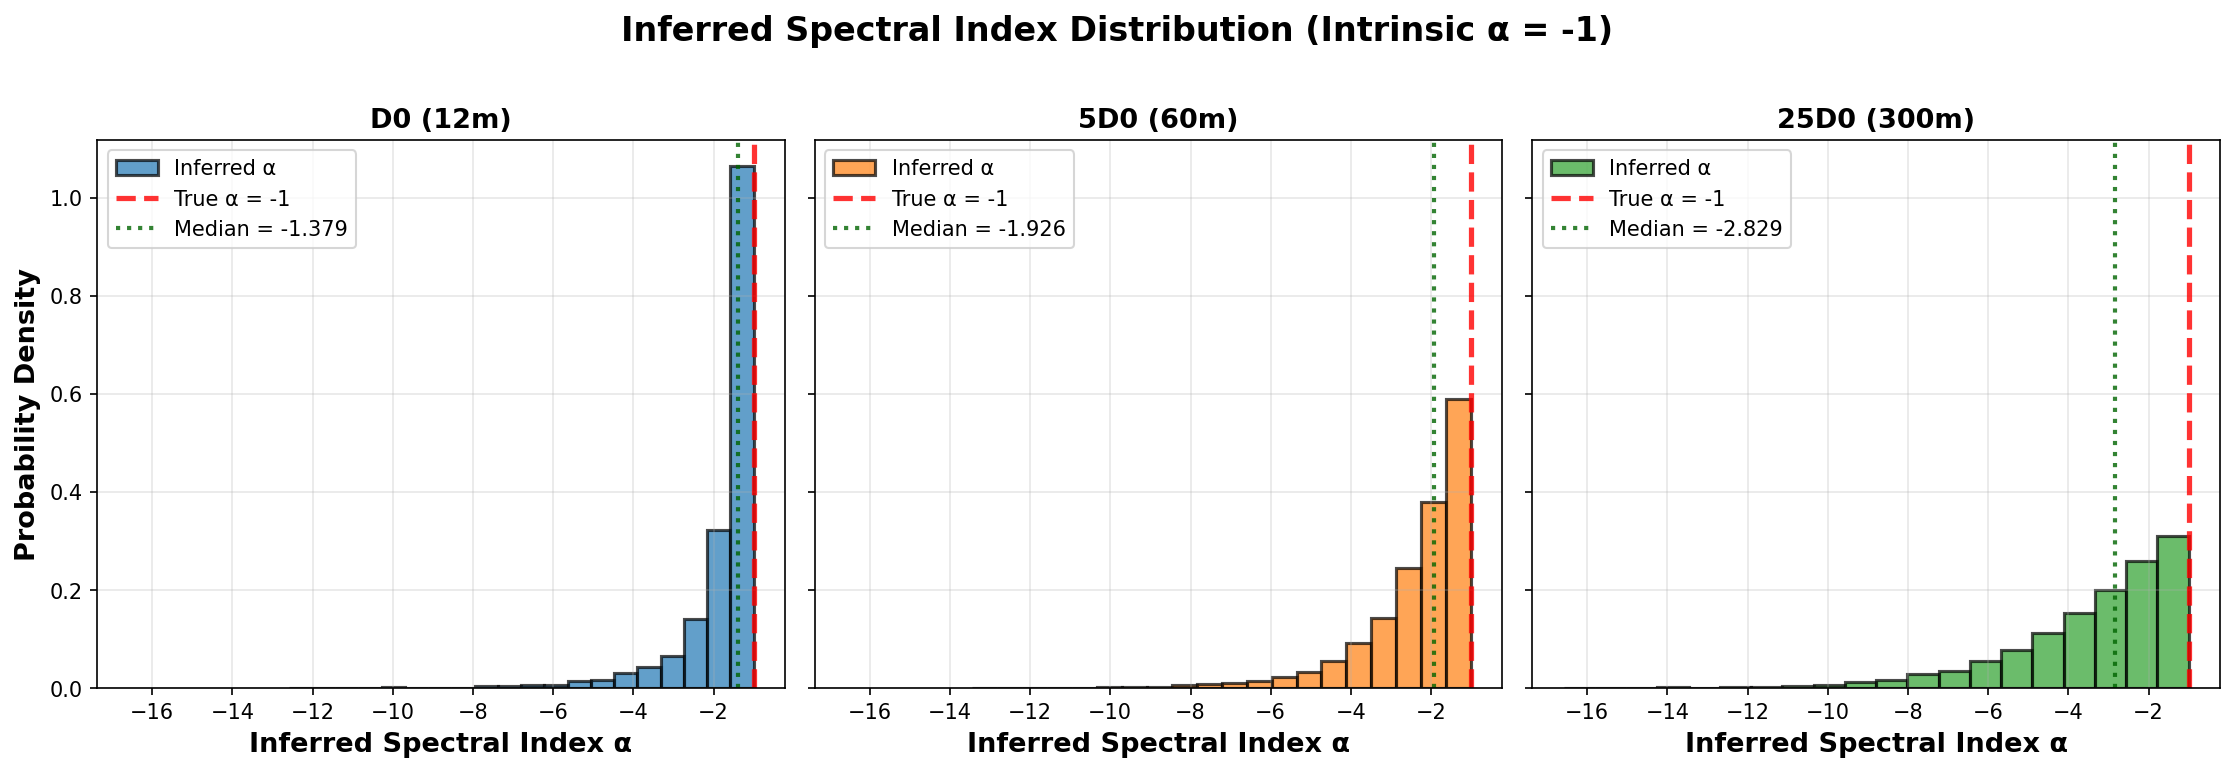

✓ Inferred spectral index distributions created!


INFERRED ALPHA STATISTICS
Telescope            N_detected      Mean α          Std α           Mean Error     
----------------------------------------------------------------------------------------------------
D0 (12m)             3060            -1.7707         1.0965          0.0117         
5D0 (60m)            4990            -2.3707         1.4216          0.0207         
25D0 (300m)          4990            -3.3784         2.0882          0.0349         



In [12]:
# ============================================================================
# PLOT: INFERRED SPECTRAL INDEX DISTRIBUTION FOR 3 TELESCOPES
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=150, sharex = True, sharey = True)

for idx, tel_key in enumerate(["d0", "5d0", "25d0"]):
    ax = axes[idx]
    
    # Get valid inferred alpha values
    valid_mask = ~np.isnan(alpha_inferred_by_telescope[tel_key])
    alpha_values = alpha_inferred_by_telescope[tel_key][valid_mask]
    
    if len(alpha_values) > 0:
        # Plot histogram
        n, bins, patches = ax.hist(alpha_values, bins=20, alpha=0.7, 
                                    color=colors_tel[tel_key], edgecolor='black', linewidth=1.5,
                                    density=True, label='Inferred α')
        
        # Plot KDE
        if len(alpha_values) > 3:
            kde = gaussian_kde(alpha_values)
            x_range = np.linspace(alpha_values.min() - 0.5, alpha_values.max() + 0.5, 200)
            # ax.plot(x_range, kde(x_range), color=colors_tel[tel_key], linewidth=2.5, label='KDE')
        
        # Add vertical lines
        mean_alpha = np.mean(alpha_values)
        median_alpha = np.median(alpha_values)
        ax.axvline(alpha_intrinsic, color='red', linestyle='--', linewidth=2.5, 
                   label=f'True α = {alpha_intrinsic}', alpha=0.8)
        # ax.axvline(mean_alpha, color='darkblue', linestyle=':', linewidth=2, 
        #            label=f'Mean = {mean_alpha:.3f}', alpha=0.8)
        ax.axvline(median_alpha, color='darkgreen', linestyle=':', linewidth=2, 
                   label=f'Median = {median_alpha:.3f}', alpha=0.8)
        # if idx == 2:
            #  ax.set_xlabel('Inferred Spectral Index α', fontsize=13, fontweight='bold')
            
        ax.set_xlabel('Inferred Spectral Index α', fontsize=13, fontweight='bold')


        if idx == 0:
            ax.set_ylabel('Probability Density', fontsize=13, fontweight='bold')
        
        ax.set_title(f'{labels_tel[tel_key]}', 
                     fontsize=13, fontweight='bold')
        ax.legend(fontsize=10, loc='upper left')
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, 'No valid data', ha='center', va='center', 
                transform=ax.transAxes, fontsize=14)
        ax.set_title(labels_tel[tel_key], fontsize=13, fontweight='bold')

plt.suptitle(f'Inferred Spectral Index Distribution (Intrinsic α = {alpha_intrinsic})', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("✓ Inferred spectral index distributions created!\n")

# Print comparison table
print(f"\n{'='*100}")
print("INFERRED ALPHA STATISTICS")
print(f"{'='*100}")
print(f"{'Telescope':<20} {'N_detected':<15} {'Mean α':<15} {'Std α':<15} {'Mean Error':<15}")
print(f"{'-'*100}")

for tel_key in ["d0", "5d0", "25d0"]:
    valid_mask = ~np.isnan(alpha_inferred_by_telescope[tel_key])
    valid_alphas = alpha_inferred_by_telescope[tel_key][valid_mask]
    valid_errors = alpha_error_by_telescope[tel_key][valid_mask]
    
    if len(valid_alphas) > 0:
        mean_alpha = np.mean(valid_alphas)
        std_alpha = np.std(valid_alphas)
        mean_error = np.mean(valid_errors)
        print(f"{labels_tel[tel_key]:<20} {np.sum(valid_mask):<15} {mean_alpha:<15.4f} {std_alpha:<15.4f} {mean_error:<15.4f}")
    else:
        print(f"{labels_tel[tel_key]:<20} {'0':<15} {'N/A':<15} {'N/A':<15} {'N/A':<15}")

print(f"{'='*100}\n")


PLOTTING: INFERRED ALPHA vs DM (SEPARATE PLOTS FOR 3 TELESCOPES)

D0 (12m):
  Total detected FRBs: 3060
  Inferred α (mean ± std): -1.7707 ± 1.0965
  Inferred α range: [-12.5949, -1.0001]
  Mean error: 0.0117

5D0 (60m):
  Total detected FRBs: 4990
  Inferred α (mean ± std): -2.3707 ± 1.4216
  Inferred α range: [-13.4449, -1.0002]
  Mean error: 0.0207

25D0 (300m):
  Total detected FRBs: 4990
  Inferred α (mean ± std): -3.3784 ± 2.0882
  Inferred α range: [-16.5922, -1.0002]
  Mean error: 0.0349



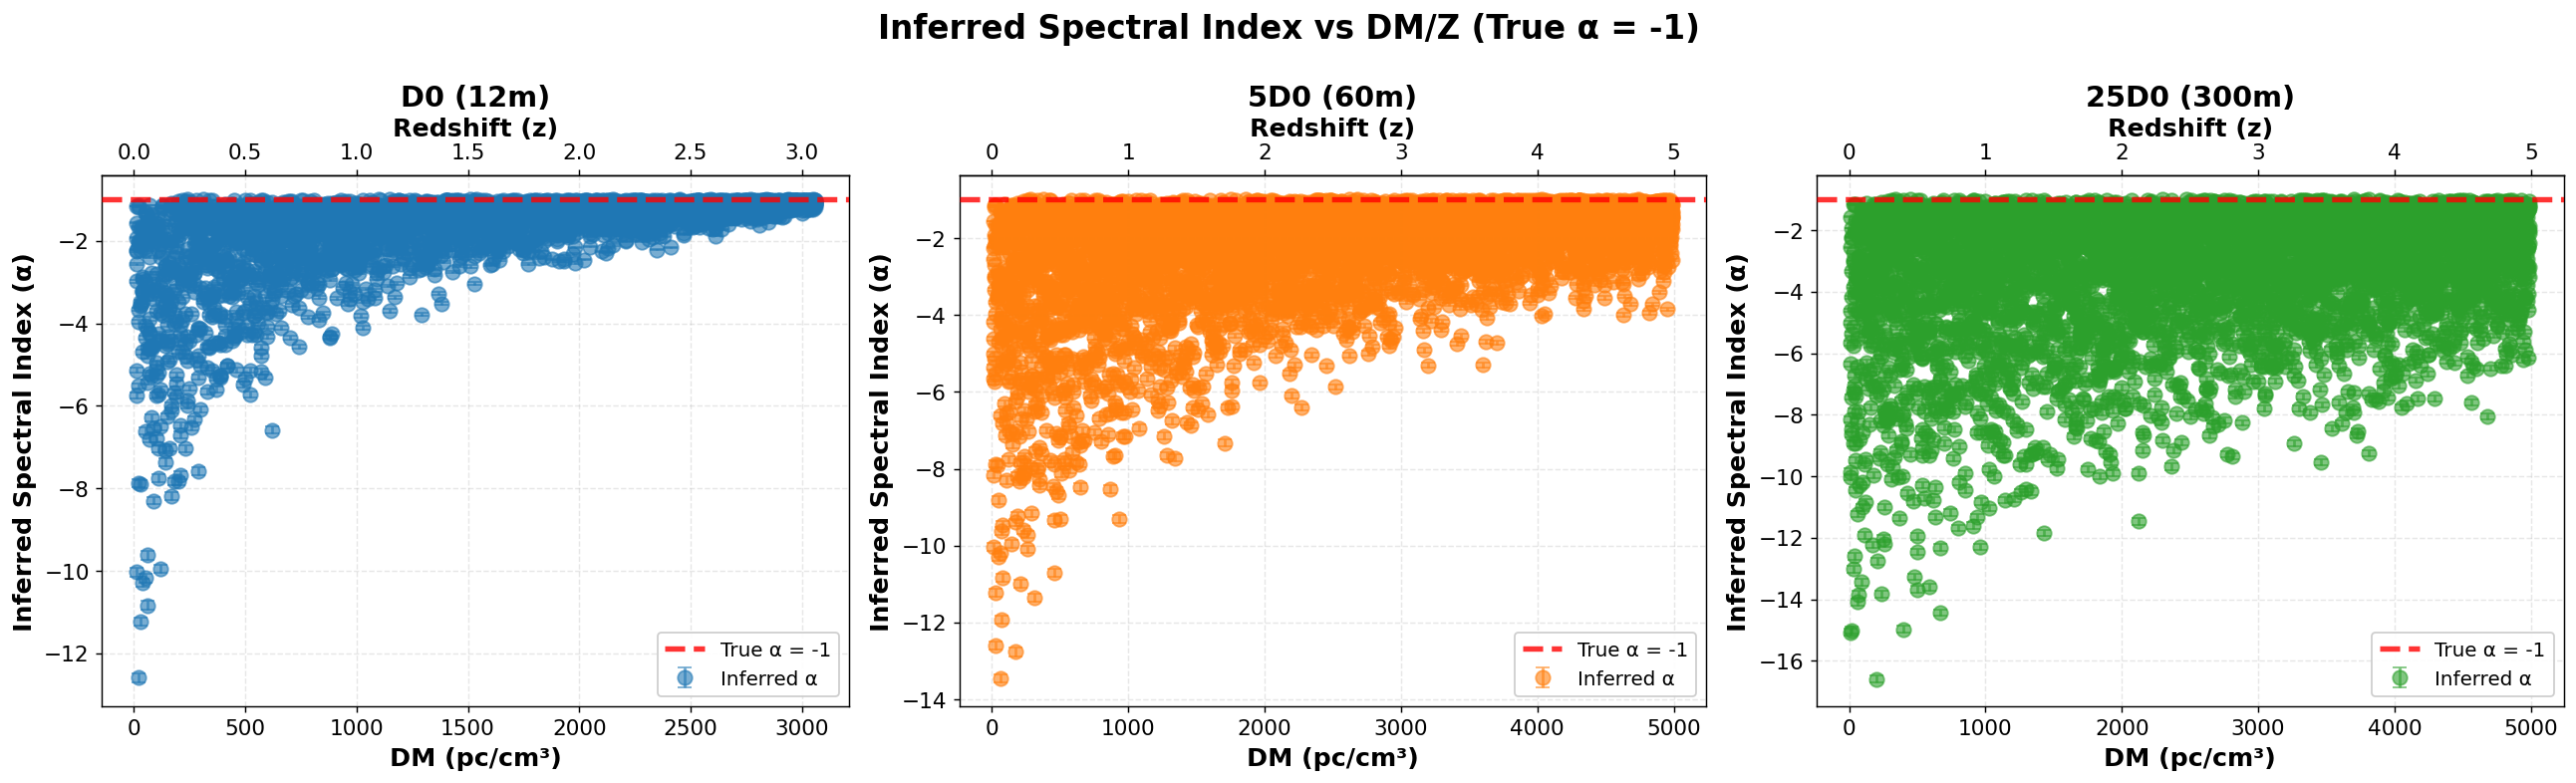

✓ Separate α vs DM/Z plots for all telescopes created!



In [16]:
# ============================================================================
# PLOT: INFERRED ALPHA vs DM/Z (SEPARATE PLOTS FOR EACH TELESCOPE)
# ============================================================================

print("\n" + "="*100)
print("PLOTTING: INFERRED ALPHA vs DM (SEPARATE PLOTS FOR 3 TELESCOPES)")
print("="*100 + "\n")

# Create figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=130)

# True alpha value
true_alpha = alpha_intrinsic

# Plot for each telescope
for plot_idx, tel_key in enumerate(["d0", "5d0", "25d0"]):
    ax_main = axes[plot_idx]
    
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        
        # Flatten arrays: for each z-bin, expand all detected FRBs
        all_dms = []
        all_alphas = []
        all_errors = []
        
        for result in results:
            dm = result['DM']
            alpha_arr = result['alpha_inferred']  # Array of inferred alphas
            error_arr = result['alpha_error']
            
            # Only include valid (non-NaN) values
            valid_mask = ~np.isnan(alpha_arr)
            
            if np.sum(valid_mask) > 0:
                all_dms.extend([dm] * np.sum(valid_mask))
                all_alphas.extend(alpha_arr[valid_mask])
                all_errors.extend(error_arr[valid_mask])
        
        all_dms = np.array(all_dms)
        all_alphas = np.array(all_alphas)
        all_errors = np.array(all_errors)
        
        # Plot with error bars
        if len(all_alphas) > 0:
            ax_main.errorbar(all_dms, all_alphas, yerr=all_errors, 
                           fmt='o', alpha=0.6, markersize=8,
                           color=colors_tel[tel_key], 
                           ecolor=colors_tel[tel_key],
                           elinewidth=1.5, capsize=4,
                           label='Inferred α', 
                           linestyle='none')
            
            # Add horizontal line for true alpha
            ax_main.axhline(true_alpha, color='red', linestyle='--', linewidth=3, 
                           label=f'True α = {true_alpha}', alpha=0.8, zorder=10)
            
            # Main axis (DM)
            ax_main.set_xlabel('DM (pc/cm³)', fontsize=14, fontweight='bold')
            ax_main.set_ylabel('Inferred Spectral Index (α)', fontsize=14, fontweight='bold')
            ax_main.set_title(f'{labels_tel[tel_key]}', fontsize=16, fontweight='bold')
            ax_main.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
            ax_main.legend(fontsize=11, loc='best', framealpha=0.95)
            ax_main.tick_params(axis='both', labelsize=12)
            
            # Secondary x-axis (redshift)
            ax_secondary = ax_main.secondary_xaxis('top', 
                                                  functions=(lambda dm: dm/1000, lambda z: z*1000))
            ax_secondary.set_xlabel('Redshift (z)', fontsize=14, fontweight='bold')
            ax_secondary.tick_params(axis='x', labelsize=12)
            
            # Print statistics
            print(f"{labels_tel[tel_key]}:")
            print(f"  Total detected FRBs: {len(all_alphas)}")
            print(f"  Inferred α (mean ± std): {np.mean(all_alphas):.4f} ± {np.std(all_alphas):.4f}")
            print(f"  Inferred α range: [{np.min(all_alphas):.4f}, {np.max(all_alphas):.4f}]")
            print(f"  Mean error: {np.mean(all_errors):.4f}\n")

plt.suptitle(f'Inferred Spectral Index vs DM/Z (True α = {true_alpha})', 
             fontsize=18, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("✓ Separate α vs DM/Z plots for all telescopes created!\n")

In [14]:
# import pickle
# out_path = "mc_all_results_cos_std.pkl"
# # out_path = "mc_all_results_cos_sch.pkl"
# # out_path = "mc_all_results_cos_sfr_sch.pkl"

# # out_path = "mc_all_results_cos_sfr_sch_smear.pkl"
# # out_path = "mc_all_results_alpha_minus_2.pkl"
# with open(out_path, "wb") as f:
#     pickle.dump(all_results, f)
# print("Saved MC pickle to", out_path)